# <span style="color:blue"> GALAXY MODEL  gruppo G<span>

## Imports and setup

In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import emcee

%matplotlib widget
plt.close("all")

## Data loading, filtering and unit conversion

In [2]:
# load the data and filter it by only picking stars near the equatorial plane (|b| < 5 deg)
gaia = Table.read("d3.gz")
mask = abs(gaia['b']) < 5
gaia_filtered = gaia[mask]

# note: we should also filter by parallax error if we dind't do it in the query!!!!

# extract the relevant columns
l = gaia_filtered["l"]
b = gaia_filtered["b"]
parallax = gaia_filtered["parallax"]
parallax_error = gaia_filtered["parallax_error"]
radial_velocity = gaia_filtered["radial_velocity"]
radial_velocity_error = gaia_filtered["radial_velocity_error"]

# print table info
gaia.info

<Table length=349153>
         name          dtype    unit                  description                 n_bad
--------------------- ------- -------- ------------------------------------------ -----
                   ra float64      deg                            Right ascension     0
                  dec float64      deg                                Declination     0
             parallax float64      mas                                   Parallax     0
       parallax_error float64      mas                 Standard error of parallax     0
                 pmra float64 mas / yr Proper motion in right ascension direction     0
                pmdec float64 mas / yr     Proper motion in declination direction     0
      phot_g_mean_mag float32      mag                      G-band mean magnitude     0
     phot_bp_mean_mag float32      mag               Integrated BP mean magnitude   422
     phot_rp_mean_mag float32      mag               Integrated RP mean magnitude   426
      radi

In [3]:
# unit conversion:
#   [velocity] = km/s
#   [distance] = kpc
#   [longitude/latitude] = radians

d_from_sun = 1 / parallax # distance from sun in kpc
l_rad = np.radians(l) # longitude in radians
b_rad = np.radians(b) # latitude in radians

print(f"Number of stars: {len(d_from_sun)}")

Number of stars: 75659


## Model definition and naive comparison

In [4]:
def distance_from_gc(l_rad, d_from_sun, R0):
    """Calculate the distance of a star from the galactic center given its longitude, distance from the sun, and the sun's distance from the galactic center.

        Parameters:
        l_rad: longitude in radians
        d_from_sun: distance from the sun in kpc
        R0: distance of the sun from the galactic center in kpc

        Returns:
        distance from the galactic center in kpc
    """
    return np.sqrt(R0**2 + d_from_sun**2 - 2.0*R0*d_from_sun*np.cos(l_rad))

def velocity_model(l_rad, d_from_sun, R0, V_rot, U0, V0):
    """Calculate the expected radial velocity of a star given its longitude, distance from the sun, and the model parameters.

        Parameters:
        l_rad: longitude in radians
        d_from_sun: distance from the sun in kpc
        R0: distance of the sun from the galactic center in kpc
        V_rot: rotation velocity of the galaxy in km/s
        U0: solar motion in the radial direction in km/s
        V0: solar motion in the tangential direction in km/s

        Returns:
        expected radial velocity in km/s

    """

    R = distance_from_gc(l_rad, d_from_sun, R0)
    
    V_lsr_term = (U0 / np.cos(l_rad)) + (V0 / np.sin(l_rad))
    V_rot_term = V_rot*((1.0 / R) - (1.0 / R0))*R0*np.sin(l_rad)

    return V_rot_term + V_lsr_term

R0 = 8.0 # kpc

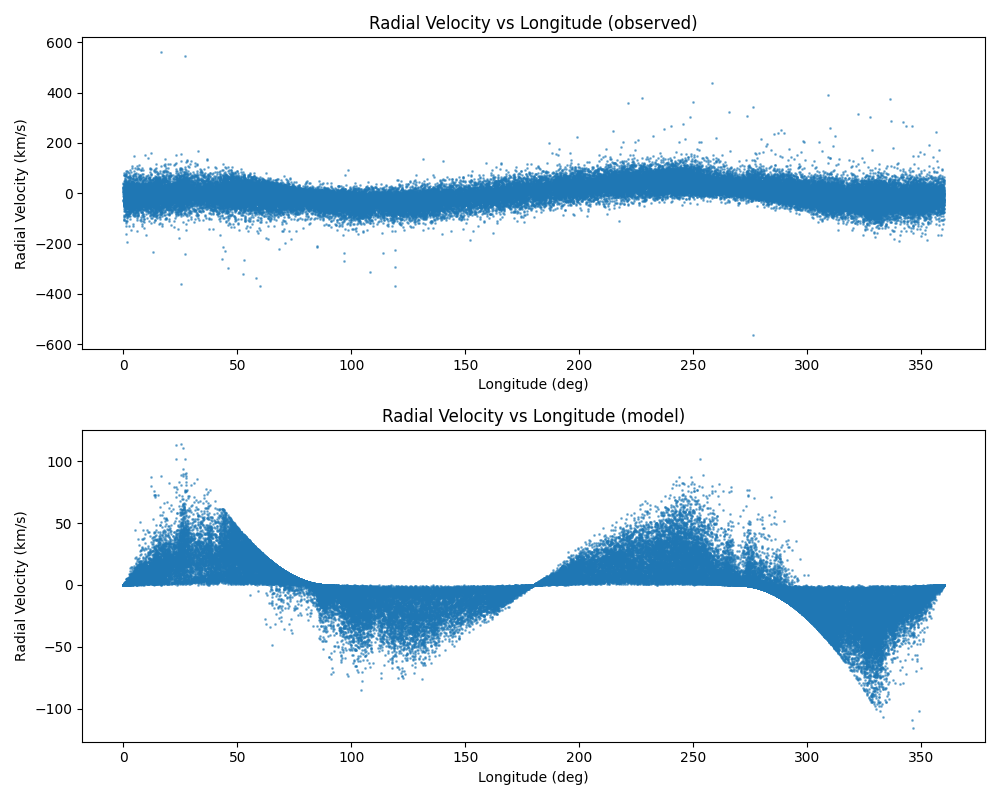

In [5]:
# plot the actual vs expected radial velocities for some initial guess of the parameters
# the lsr term for now is 0

V_rot = 200.0 # km/s
U0 = 0.0 # km/s
V0 = 0.0 # km/s

V_rad_exp = velocity_model(l_rad, d_from_sun, R0, V_rot, U0, V0)

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.scatter(l, radial_velocity, s=1, label="Observed", alpha=0.5)
plt.xlabel("Longitude (deg)")
plt.ylabel("Radial Velocity (km/s)")
plt.title("Radial Velocity vs Longitude (observed)")

plt.subplot(2, 1, 2)
plt.scatter(l, V_rad_exp, s=1, label="Expected", alpha=0.5)
plt.xlabel("Longitude (deg)")
plt.ylabel("Radial Velocity (km/s)")
plt.title("Radial Velocity vs Longitude (model)")

plt.tight_layout()

plt.show()

## Statistical analysis

### Probability

In [6]:
def log_likelihood(theta, V_rad, l, d, error):
    V_rot, log_sigma_rot = theta
    
    R = distance_from_gc(l, d, R0)

    # V_rad as function of V_rot (and l)
    model =  velocity_model(l, d, R0, V_rot, 0.0, 0.0)

    sigma2 = error**2 + np.exp(log_sigma_rot)**2

    return -np.sum(np.log(np.sqrt(2.0*np.pi*sigma2)) + (0.5*(V_rad - model)**2)/sigma2)

def log_prior(theta):
    V_rot,  log_sigma_rot = theta

    # set the prior to be uniform, but set some bounds on the parameters
    if V_rot < 0.0 or V_rot > 400.0:
        if log_sigma_rot < 0.0 or log_sigma_rot > 5.0:
            return -np.inf

    return 0.0

def log_probability(theta, V_rad, l, d, error ):
    return log_likelihood(theta, V_rad, l, d, error) + log_prior(theta)

### Max likelyhood

In [7]:
# initial guess for the parameters
# we set some reasonable start values (well inside the prior bounds), then add some random noise to create the initial positions of the walkers
p0 = [100.0, np.log(20.0)] # initial guess for the parameters
pos = p0 + np.array([10.0, 0.5]) * np.random.randn(20, 2)   # 20 walkers, 2 parameters (V_rot, log_sigma_rot)

# number of walkers and dimensions can be inferred from the shape of the pos array
nwal, dim = pos.shape
num_iters = 10

sampler = emcee.EnsembleSampler(nwal, dim, log_probability, args=(radial_velocity, l_rad, d_from_sun, radial_velocity_error))
sampler.run_mcmc(pos, num_iters, progress=True)

100%|██████████| 10/10 [00:01<00:00,  8.03it/s]


State([[140.56790955   3.6346576 ]
 [ 99.81893075   2.93009136]
 [119.87712697   3.54845598]
 [104.77224997   3.57243068]
 [100.27261092   3.17828791]
 [ 97.71830728   3.49498268]
 [109.53117454   3.52909874]
 [152.28431637   3.56167118]
 [107.65149133   3.43724899]
 [ 99.99073857   3.48106236]
 [ 97.85882473   3.47768785]
 [111.20415291   3.29338851]
 [ 99.09195999   3.64126191]
 [167.62640666   3.57126222]
 [ 92.84669498   3.54063369]
 [ 97.80199665   3.6141841 ]
 [121.27698215   3.22029577]
 [ 97.88135978   3.18836928]
 [ 99.55477989   3.36367189]
 [113.44595137   3.65092934]], log_prob=[-378267.27423997 -435276.14346456 -378938.01138855 -379618.9361107
 -397895.03342953 -380897.46899158 -379649.57070122 -377694.54652914
 -381502.73586765 -381000.57624088 -381226.32759994 -387528.32551217
 -380007.35481592 -377387.3311467  -380592.29776164 -379974.04843605
 -391788.661109   -397222.86144461 -384845.04351786 -379386.69298772], blobs=None, random_state=('MT19937', array([ 660063736, 1